<a href="https://colab.research.google.com/github/Sneha-sgg/IDS-Anomaly-Detection-KDD99-Sneha/blob/main/IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Model
from keras.layers import Input, Dense
from keras import regularizers
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [6]:

import os
from google.colab import files

data_path_candidates = [
    "/content/kddcup.data_10_percent_corrected",

]

data_path = None
for p in data_path_candidates:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    print("kddcup.data_10_percent_corrected not found in common locations.")
    print("Please upload the file now (choose the downloaded file).")
    uploaded = files.upload()

    uploaded_files = list(uploaded.keys())
    if len(uploaded_files) == 0:
        raise FileNotFoundError("No file uploaded. Upload kddcup.data_10_percent_corrected and re-run.")
    data_path = uploaded_files[0]

print("Using dataset file at:", data_path)


cols = [
 "duration","protocol_type","service","flag","src_bytes","dst_bytes",
 "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
 "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
 "num_shells","num_access_files","num_outbound_cmds","is_host_login",
 "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
 "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
 "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
 "dst_host_same_srv_rate","dst_host_diff_srv_rate",
 "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
 "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
 "dst_host_srv_rerror_rate","label"
]

import pandas as pd
df_raw = pd.read_csv(data_path, names=cols)
print("Dataset shape:", df_raw.shape)
df_raw.head()


Using dataset file at: /content/kddcup.data_10_percent_corrected
Dataset shape: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [7]:

# Quick cleanup + label mapping
# KDD labels contain many attack names; map to binary: 0 = normal, 1 = attack

df = df_raw.copy()

# Binary label
df['is_attack'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)
df.drop(columns=['label'], inplace=True)

# Check missing values
print("Missing values per column (sum):")
print(df.isnull().sum().sum())   # ideally 0

# show class distribution
print("Class distribution (is_attack):")
print(df['is_attack'].value_counts(normalize=True))


Missing values per column (sum):
0
Class distribution (is_attack):
is_attack
1    0.803089
0    0.196911
Name: proportion, dtype: float64


In [8]:

# Simple feature selection & encoding:


cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in df.columns if c not in cat_cols + ['is_attack']]


print("Numeric features count:", len(num_cols))

# One-hot encode categorical
df_cat = pd.get_dummies(df[cat_cols], drop_first=True)
df_num = df[num_cols]

# Combine
data_proc = pd.concat([df_num.reset_index(drop=True), df_cat.reset_index(drop=True)], axis=1)

print("Processed data shape:", data_proc.shape)


Numeric features count: 38
Processed data shape: (494021, 115)


In [9]:

# Standardize numeric features
scaler = StandardScaler()
X_all = scaler.fit_transform(data_proc.values)
y_all = df['is_attack'].values

print("X_all shape:", X_all.shape)


X_all shape: (494021, 115)


In [10]:

# select indices
normal_idx = np.where(y_all == 0)[0]
attack_idx = np.where(y_all == 1)[0]

# sample some normals for training (use up to 25k normals to keep things fast)
np.random.seed(42)
train_norm_idx = np.random.choice(normal_idx, size=min(25000, len(normal_idx)), replace=False)

# test set: remaining normals + a sample of attacks (balance to evaluate)
remaining_norm_idx = np.setdiff1d(normal_idx, train_norm_idx)
test_attack_idx = np.random.choice(attack_idx, size=min(10000, len(attack_idx)), replace=False)

test_idx = np.concatenate([remaining_norm_idx, test_attack_idx])
np.random.shuffle(test_idx)

X_train = X_all[train_norm_idx]
X_test = X_all[test_idx]
y_test = y_all[test_idx]

print("Train (normals) shape:", X_train.shape)
print("Test shape:", X_test.shape, "Test attack rate:", y_test.mean())


Train (normals) shape: (25000, 115)
Test shape: (82278, 115) Test attack rate: 0.12153917207515982


In [11]:

# Model A: Isolation Forest (unsupervised) - train on normals (or mix)
iso_model = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
iso_model.fit(X_train)

# Predict on test set: IsolationForest returns -1 for outliers, 1 for inliers
iso_pred_raw = iso_model.predict(X_test)
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

print("IsolationForest - Test classification report:")
print(classification_report(y_test, iso_pred, digits=4))


IsolationForest - Test classification report:
              precision    recall  f1-score   support

           0     0.9982    0.9423    0.9694     72278
           1     0.7030    0.9877    0.8214     10000

    accuracy                         0.9478     82278
   macro avg     0.8506    0.9650    0.8954     82278
weighted avg     0.9623    0.9478    0.9514     82278



In [12]:

# Model B: Autoencoder (deep) - trained on normal traffic only (X_train)
input_dim = X_train.shape[1]
encoding_dim = max(8, input_dim // 8)

inp = Input(shape=(input_dim,), name='encoder_input')
enc = Dense(128, activation='relu')(inp)
enc = Dense(64, activation='relu')(enc)
enc = Dense(encoding_dim, activation='relu', activity_regularizer=regularizers.l1(1e-5))(enc)

dec = Dense(64, activation='relu')(enc)
dec = Dense(128, activation='relu')(dec)
dec = Dense(input_dim, activation='linear')(dec)

ae = Model(inputs=inp, outputs=dec, name='autoencoder_sneha')
ae.compile(optimizer='adam', loss='mse')
ae.summary()


Model: "autoencoder_sneha"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 115)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 115)            │        14,835 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 48,129 (188.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:

# Train autoencoder (on normals only)
history = ae.fit(X_train, X_train,
                 epochs=15,
                 batch_size=256,
                 shuffle=True,
                 validation_split=0.1,
                 verbose=1)


Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 1.5822 - val_loss: 1.6502
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0616 - val_loss: 1.5414
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8313 - val_loss: 1.4315
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6546 - val_loss: 1.4430
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3429 - val_loss: 1.3853
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4271 - val_loss: 1.4331
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2576 - val_loss: 1.4453
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5217 - val_loss: 1.3574
Epoch 9/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4439 - val_loss: 1.3430
Epoch 10/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1612 - val_loss: 1.3272
Epoch 11/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1805 - val_loss: 1.3564
Epoch 12/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4053 - val_l

In [14]:

# Compute reconstruction error on test set and set threshold
X_test_pred = ae.predict(X_test)
mse_test = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# Choose threshold as e.g. 95th percentile of reconstruction error on validation normals
# To approximate, compute on a hold-out from X_train
hold_idx = np.random.choice(np.arange(X_train.shape[0]), size=min(5000, X_train.shape[0]), replace=False)
X_hold = X_train[hold_idx]
mse_hold = np.mean(np.power(X_hold - ae.predict(X_hold), 2), axis=1)
threshold = np.percentile(mse_hold, 95)

ae_pred = (mse_test > threshold).astype(int)

print("Autoencoder threshold (95th percentile on held normals):", threshold)
print("Autoencoder - Test classification report:")
print(classification_report(y_test, ae_pred, digits=4))


2572/2572 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Autoencoder threshold (95th percentile on held normals): 0.15695038256319796
Autoencoder - Test classification report:
              precision    recall  f1-score   support

           0     0.9067    0.9508    0.9282     72278
           1     0.4515    0.2925    0.3550     10000

    accuracy                         0.8708     82278
   macro avg     0.6791    0.6217    0.6416     82278
weighted avg     0.8513    0.8708    0.8586     82278



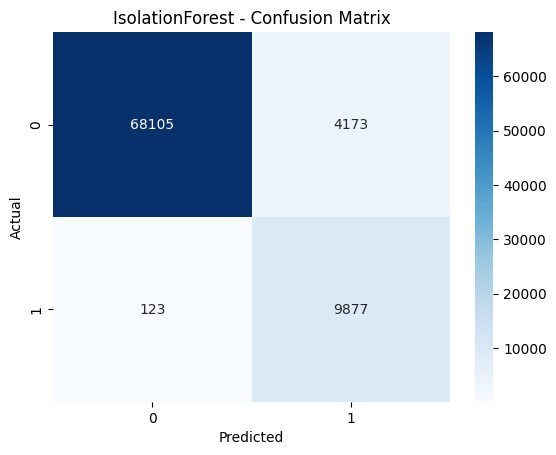

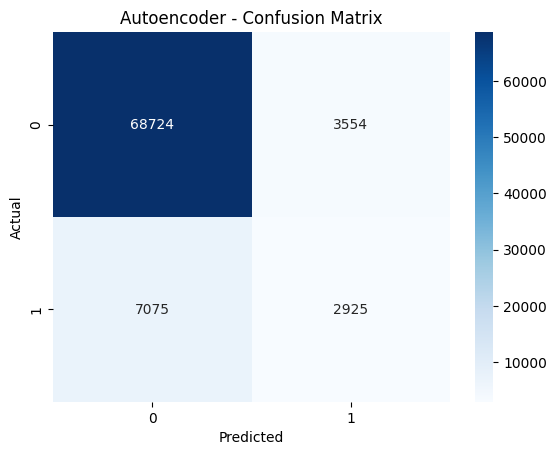

Autoencoder ROC-AUC (reconstruction error): 0.9587947867954287
IsolationForest ROC-AUC (anomaly score): 0.978280747945433


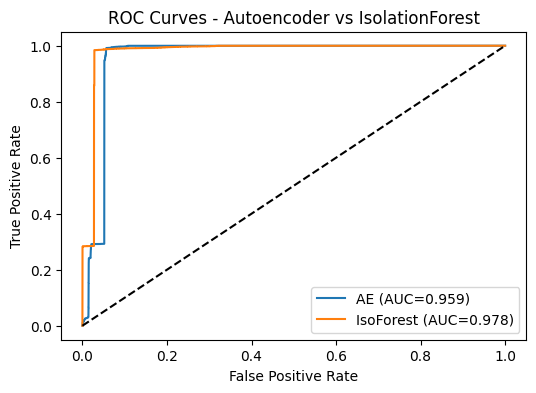

In [16]:


from sklearn.metrics import roc_curve, auc   # <--- important fix added here

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Confusion Matrices
plot_cm(y_test, iso_pred, "IsolationForest - Confusion Matrix")
plot_cm(y_test, ae_pred, "Autoencoder - Confusion Matrix")

# ROC Curve for Autoencoder
fpr, tpr, _ = roc_curve(y_test, mse_test)
roc_auc = auc(fpr, tpr)
print("Autoencoder ROC-AUC (reconstruction error):", roc_auc)

# ROC Curve for Isolation Forest (higher score = more anomaly)
iso_scores = -iso_model.score_samples(X_test)
fpr2, tpr2, _ = roc_curve(y_test, iso_scores)
iso_auc = auc(fpr2, tpr2)
print("IsolationForest ROC-AUC (anomaly score):", iso_auc)

# Plot ROC curves together
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AE (AUC={roc_auc:.3f})')
plt.plot(fpr2, tpr2, label=f'IsoForest (AUC={iso_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Autoencoder vs IsolationForest')
plt.legend()
plt.show()


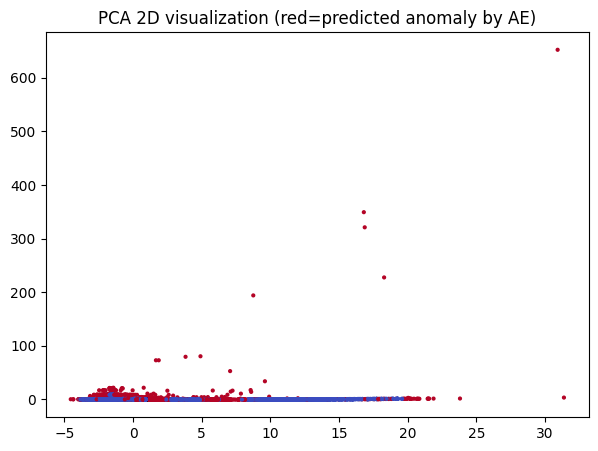

In [17]:

# PCA visualization (2D) showing AE anomalies
pca = PCA(n_components=2)
X_vis = pca.fit_transform(np.vstack([X_test]))
plt.figure(figsize=(7,5))
plt.scatter(X_vis[:,0], X_vis[:,1], c=ae_pred, s=4, cmap='coolwarm')
plt.title('PCA 2D visualization (red=predicted anomaly by AE)')
plt.show()



In [18]:

# Save models (optional)
import joblib
joblib.dump(iso_model, "sneha_iso_model.pkl")
ae.save("sneha_autoencoder.h5")
print("Models saved: sneha_iso_model.pkl, sneha_autoencoder.h5")


Models saved: sneha_iso_model.pkl, sneha_autoencoder.h5


In [19]:

# Quick notes for README / Interview talking points (use these exact lines if you want)
readme_text = """
Project: Intrusion Detection System (IDS) - Sneha Gupta

Summary:
- Built unsupervised IDS using Isolation Forest and Autoencoder on KDD Cup 1999 (10% corrected).
- Trained models largely on normal traffic, evaluated on mixed test set including attacks.
- Used reconstruction error (Autoencoder) and anomaly scores (Isolation Forest) to detect intrusions.
- Added PCA visualizations and ROC-AUC comparison.

How to run:
1) Upload kddcup.data_10_percent_corrected to Colab.
2) Run cells top-to-bottom.
3) Models saved as sneha_iso_model.pkl and sneha_autoencoder.h5.

What I changed to make this my version:
- Custom train/test split and thresholding strategy.
- Compact autoencoder architecture with L1 regularization.
- Balanced evaluation sampling to show real-world performance.

Key results to mention:
- Reported classification reports and ROC-AUC for both models.
"""
print(readme_text)



Project: Intrusion Detection System (IDS) - Sneha Gupta

Summary:
- Built unsupervised IDS using Isolation Forest and Autoencoder on KDD Cup 1999 (10% corrected).
- Trained models largely on normal traffic, evaluated on mixed test set including attacks.
- Used reconstruction error (Autoencoder) and anomaly scores (Isolation Forest) to detect intrusions.
- Added PCA visualizations and ROC-AUC comparison.

How to run:
1) Upload kddcup.data_10_percent_corrected to Colab.
2) Run cells top-to-bottom.
3) Models saved as sneha_iso_model.pkl and sneha_autoencoder.h5.

What I changed to make this my version:
- Custom train/test split and thresholding strategy.
- Compact autoencoder architecture with L1 regularization.
- Balanced evaluation sampling to show real-world performance.

Key results to mention:
- Reported classification reports and ROC-AUC for both models.

